# NLTK Sentiment Analysis 

In [2]:
# %pip install nltk

In [3]:
import os

try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()

os.chdir(base_dir)

os.getcwd()

'/opt/notebooks/psalms-text-comparison'

In [4]:
os.listdir("data")

['cleaned_psalm_verses.csv', 'grouped_psalm.csv']

In [5]:
import pandas as pd
psalm_verses = pd.read_csv("data/cleaned_psalm_verses.csv")
psalm_verses

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,tradition,text,psalm_num,verse_num,verse
0,Orthodox,Bible,1,1,Blessed is the man Who walks not in the counse...
1,Orthodox,Bible,1,2,But his will is in the law of the Lord And in ...
2,Orthodox,Bible,1,3,He shall be like a tree Planted by streams of ...
3,Orthodox,Bible,1,4,Not so are the ungodly not so But they are lik...
4,Orthodox,Bible,1,5,Therefore the ungodly shall not rise in the ju...
...,...,...,...,...,...
4937,Orthodox,Psalter,150,1,Praise God in His holy ones; praise Him in the...
4938,Orthodox,Psalter,150,2,Praise Him for His mighty acts; praise Him acc...
4939,Orthodox,Psalter,150,3,Praise Him with the sound of the trumpet; prai...
4940,Orthodox,Psalter,150,4,Praise Him with the timbrel and dance; praise ...


In [6]:
psalms = pd.read_csv("data/grouped_psalm.csv")
psalms

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...
...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio..."
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ..."


In [7]:
from nltk.classify import NaiveBayesClassifier
from nltk.corpus import subjectivity
from nltk.sentiment import SentimentAnalyzer
from nltk.sentiment.util import *

## VADER 
Valence Aware Dictionary and sEntiment Reasoner is the most common tool for unlabeled data. It uses a rule-based lexicon to provide intensity scores.

In [8]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer


# Download required lexicon
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


### Per Verse

In [9]:
psalm_verses['vader_score'] = None  # initialize column

for index, row in psalm_verses.iterrows():
    text = row['verse']
    psalm_verses.at[index, 'vader_score'] = sia.polarity_scores(text)

In [10]:
scores = psalm_verses['verse'].apply(sia.polarity_scores).apply(pd.Series)
psalm_verses = pd.concat([psalm_verses, scores], axis=1)

psalm_verses

,tradition,text,psalm_num,verse_num,verse,vader_score,neg,neu,pos,compound
0,Orthodox,Bible,1,1,Blessed is the man Who walks not in the counse...,"{'neg': 0.099, 'neu': 0.783, 'pos': 0.117, 'co...",0.099,0.783,0.117,0.1531
1,Orthodox,Bible,1,2,But his will is in the law of the Lord And in ...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,1.000,0.000,0.0000
2,Orthodox,Bible,1,3,He shall be like a tree Planted by streams of ...,"{'neg': 0.0, 'neu': 0.918, 'pos': 0.082, 'comp...",0.000,0.918,0.082,0.3612
3,Orthodox,Bible,1,4,Not so are the ungodly not so But they are lik...,"{'neg': 0.0, 'neu': 0.866, 'pos': 0.134, 'comp...",0.000,0.866,0.134,0.5023
4,Orthodox,Bible,1,5,Therefore the ungodly shall not rise in the ju...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.000,1.000,0.000,0.0000
...,...,...,...,...,...,...,...,...,...,...
4937,Orthodox,Psalter,150,1,Praise God in His holy ones; praise Him in the...,"{'neg': 0.0, 'neu': 0.542, 'pos': 0.458, 'comp...",0.000,0.542,0.458,0.8519
4938,Orthodox,Psalter,150,2,Praise Him for His mighty acts; praise Him acc...,"{'neg': 0.0, 'neu': 0.644, 'pos': 0.356, 'comp...",0.000,0.644,0.356,0.8020
4939,Orthodox,Psalter,150,3,Praise Him with the sound of the trumpet; prai...,"{'neg': 0.0, 'neu': 0.644, 'pos': 0.356, 'comp...",0.000,0.644,0.356,0.8020
4940,Orthodox,Psalter,150,4,Praise Him with the timbrel and dance; praise ...,"{'neg': 0.0, 'neu': 0.625, 'pos': 0.375, 'comp...",0.000,0.625,0.375,0.8020


### Per Psalm

In [11]:
psalms_temp = psalms.copy()
psalms_temp

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...
...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio..."
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ..."


In [12]:
psalms_temp['vader_score'] = None  # initialize column

for index, row in psalms_temp.iterrows():
    text = row['verse']
    psalms_temp.at[index, 'vader_score'] = sia.polarity_scores(text)

In [13]:
psalms_temp

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,vader_score
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...,"{'neg': 0.015, 'neu': 0.92, 'pos': 0.064, 'com..."
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...,"{'neg': 0.12, 'neu': 0.787, 'pos': 0.093, 'com..."
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...,"{'neg': 0.089, 'neu': 0.786, 'pos': 0.126, 'co..."
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...,"{'neg': 0.092, 'neu': 0.748, 'pos': 0.159, 'co..."
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...,"{'neg': 0.13, 'neu': 0.712, 'pos': 0.157, 'com..."
...,...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...,"{'neg': 0.095, 'neu': 0.765, 'pos': 0.141, 'co..."
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio...","{'neg': 0.0, 'neu': 0.794, 'pos': 0.206, 'comp..."
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...,"{'neg': 0.018, 'neu': 0.749, 'pos': 0.233, 'co..."
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ...","{'neg': 0.017, 'neu': 0.759, 'pos': 0.224, 'co..."


In [14]:
scores = psalms_temp['vader_score'].apply(pd.Series)
psalms = pd.concat([psalms_temp, scores], axis=1)

psalms

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,vader_score,neg,neu,pos,compound
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...,"{'neg': 0.015, 'neu': 0.92, 'pos': 0.064, 'com...",0.015,0.920,0.064,0.7783
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...,"{'neg': 0.12, 'neu': 0.787, 'pos': 0.093, 'com...",0.120,0.787,0.093,-0.6486
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...,"{'neg': 0.089, 'neu': 0.786, 'pos': 0.126, 'co...",0.089,0.786,0.126,0.8020
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...,"{'neg': 0.092, 'neu': 0.748, 'pos': 0.159, 'co...",0.092,0.748,0.159,0.8919
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...,"{'neg': 0.13, 'neu': 0.712, 'pos': 0.157, 'com...",0.130,0.712,0.157,0.7774
...,...,...,...,...,...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...,"{'neg': 0.095, 'neu': 0.765, 'pos': 0.141, 'co...",0.095,0.765,0.141,0.8417
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio...","{'neg': 0.0, 'neu': 0.794, 'pos': 0.206, 'comp...",0.000,0.794,0.206,0.9808
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...,"{'neg': 0.018, 'neu': 0.749, 'pos': 0.233, 'co...",0.018,0.749,0.233,0.9946
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ...","{'neg': 0.017, 'neu': 0.759, 'pos': 0.224, 'co...",0.017,0.759,0.224,0.9870


It provides us the overall sentiment score and its value ranges from -1 to 1, -1 being the strong negative sentiment and 1 being the strong positive sentiment.

**Word-level sentiment scores**

Each word in the text is looked up in VADER’s lexicon and assigned a sentiment valence (e.g., “good” ≈ +1.9, “bad” ≈ −2.5).

**Adjustments (heuristics)**

VADER modifies these scores based on:
- Intensifiers (“very”, “extremely” → boost)
- Negations (“not good” → flips/lowers)
- Punctuation (!!! increases intensity)
- Capitalization (ALL CAPS adds emphasis)
- Conjunctions (“but” shifts emphasis to later clause)


$$
S = \sum_{i} v_i
$$

$$
compound = \frac{s}{\sqrt{S^2 + \alpha}}
$$

where:
- S = sum of valance scores
- $\alpha$ = 15 (a normalization constant)

In [15]:

def map_vader_score(score):
    # Map to categories based on standard thresholds
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

In [16]:
psalms['vader_category'] = psalms['compound'].apply(map_vader_score)
psalms

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,vader_score,neg,neu,pos,compound,vader_category
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...,"{'neg': 0.015, 'neu': 0.92, 'pos': 0.064, 'com...",0.015,0.920,0.064,0.7783,Positive
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...,"{'neg': 0.12, 'neu': 0.787, 'pos': 0.093, 'com...",0.120,0.787,0.093,-0.6486,Negative
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...,"{'neg': 0.089, 'neu': 0.786, 'pos': 0.126, 'co...",0.089,0.786,0.126,0.8020,Positive
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...,"{'neg': 0.092, 'neu': 0.748, 'pos': 0.159, 'co...",0.092,0.748,0.159,0.8919,Positive
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...,"{'neg': 0.13, 'neu': 0.712, 'pos': 0.157, 'com...",0.130,0.712,0.157,0.7774,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...,"{'neg': 0.095, 'neu': 0.765, 'pos': 0.141, 'co...",0.095,0.765,0.141,0.8417,Positive
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio...","{'neg': 0.0, 'neu': 0.794, 'pos': 0.206, 'comp...",0.000,0.794,0.206,0.9808,Positive
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...,"{'neg': 0.018, 'neu': 0.749, 'pos': 0.233, 'co...",0.018,0.749,0.233,0.9946,Positive
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ...","{'neg': 0.017, 'neu': 0.759, 'pos': 0.224, 'co...",0.017,0.759,0.224,0.9870,Positive


## Graphing the Vader Score

In [17]:
psalms = psalms.reset_index(drop=True)


In [18]:
bible = psalms[psalms["text"] == "Bible"].copy().reset_index(drop=True)
psalter = psalms[psalms["text"] == "Psalter"] .copy().reset_index(drop=True)


bible["row"] = bible.index // 10
bible["col"] = bible.index % 10


psalter["row"] = psalter.index // 10
psalter["col"] = psalter.index % 10

In [19]:
pd.pivot_table(data = psalms, index=['text', 'vader_category'], values='tradition', aggfunc='count')

tradition
text    vader_category           
Bible   Negative               32
        Neutral                 1
        Positive              118
Psalter Negative               27
        Neutral                 1
        Positive              122

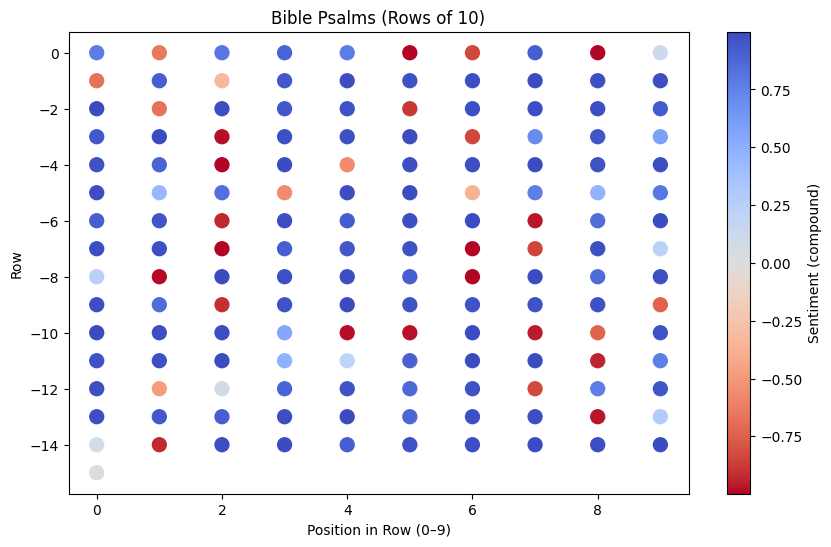

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))


plt.scatter(
    bible["col"],
    -bible["row"],   # negative so it grows downward like a table
    c=bible["compound"],
    cmap="coolwarm_r",
    s=100
)

plt.title("Bible Psalms (Rows of 10)")
plt.xlabel("Position in Row (0–9)")
plt.ylabel("Row")
plt.colorbar(label="Sentiment (compound)")
plt.show()

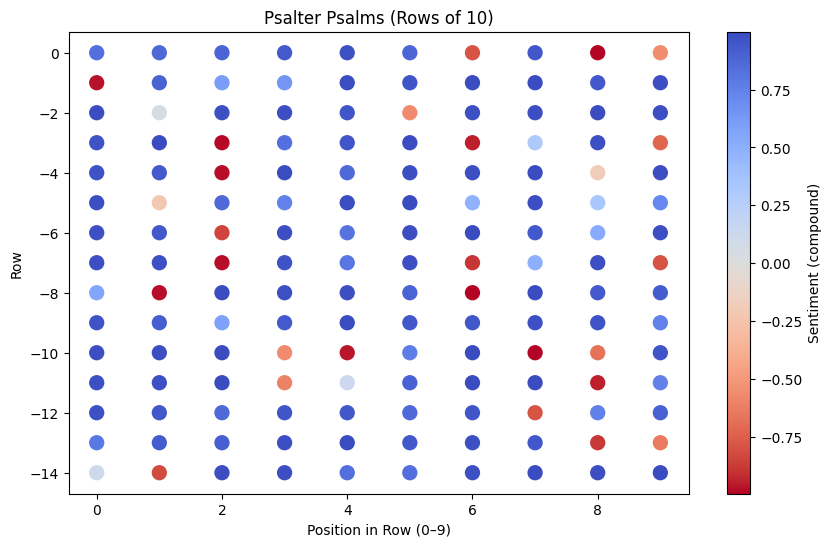

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(
    psalter["col"],
    -psalter["row"],
    c=psalter["compound"],
    cmap="coolwarm_r",
    s=100
)

plt.title("Psalter Psalms (Rows of 10)")
plt.xlabel("Position in Row (0–9)")
plt.ylabel("Row")
plt.colorbar(label="Sentiment (compound)")
plt.show()

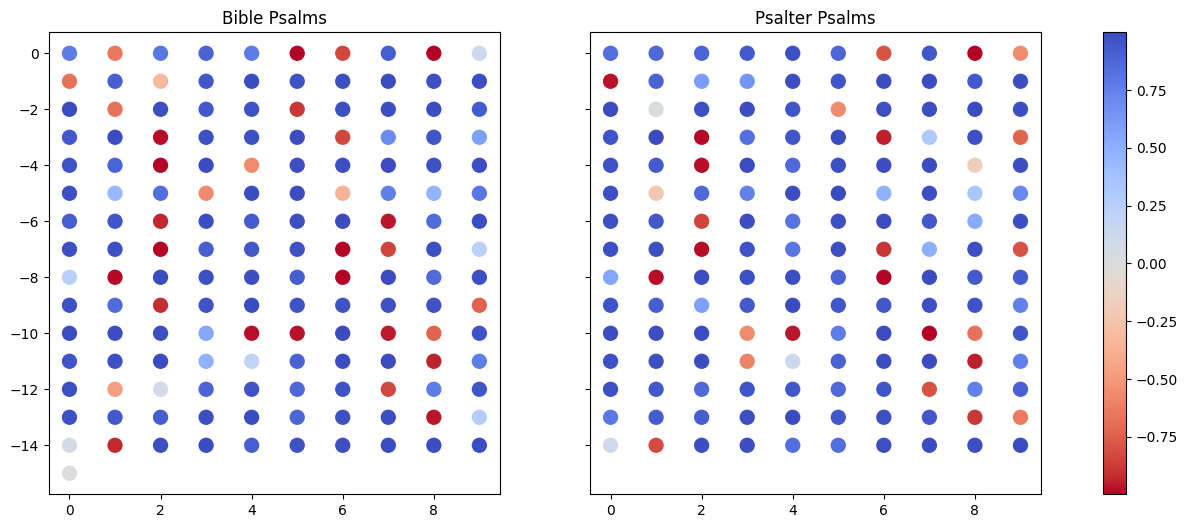

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

axes[0].scatter(bible["col"], -bible["row"], c=bible["compound"], cmap="coolwarm_r", s=100)
axes[0].set_title("Bible Psalms")

axes[1].scatter(psalter["col"], -psalter["row"], c=psalter["compound"], cmap="coolwarm_r", s=100)
axes[1].set_title("Psalter Psalms")

plt.colorbar(axes[0].collections[0], ax=axes)
plt.show()

In [23]:
pivot = pd.pivot_table(
    data=psalms,
    index='vader_category',
    columns='text',
    values='tradition',
    aggfunc='count',
    fill_value=0
)

In [24]:
pivot["difference"] = pivot["Psalter"] - pivot["Bible"]

In [25]:
pivot_norm = pivot.div(pivot.sum(axis=0), axis=1)
pivot_norm["difference"] = abs(pivot_norm["Psalter"] - pivot_norm["Bible"])

In [26]:
pivot

text,Bible,Psalter,difference
vader_category,,,
Negative,32,27,-5
Neutral,1,1,0
Positive,118,122,4


<Axes: xlabel='vader_category'>

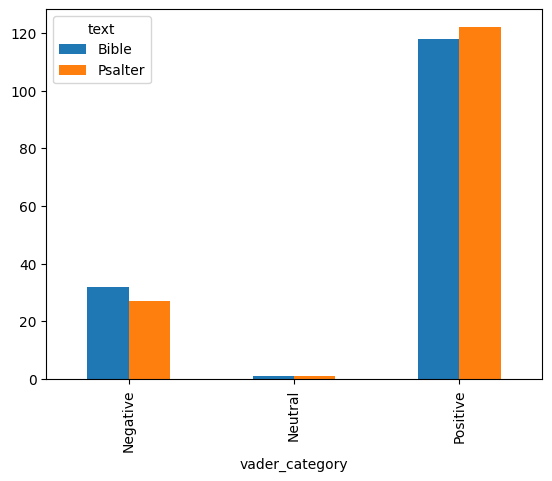

In [27]:
 pivot[["Bible", "Psalter"]].plot(kind="bar")

## TextBlob

In [28]:
%pip install TextBlob

Note: you may need to restart the kernel to use updated packages.


**Polarity**: the measure of the emotional tone of the text

**Subjectivity**: content influenced by personal opinions, feelings, beliefs, or biases, rather than pure factual information.

In [48]:
from textblob import TextBlob

psalms["polarity"] = psalms["verse"].apply(lambda x: TextBlob(x).sentiment.polarity)
psalms["subjectivity"] = psalms["verse"].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [30]:
psalms

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,vader_score,neg,neu,pos,compound,vader_category,polarity,subjectivity
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...,"{'neg': 0.015, 'neu': 0.92, 'pos': 0.064, 'com...",0.015,0.920,0.064,0.7783,Positive,0.000000,0.000000
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...,"{'neg': 0.12, 'neu': 0.787, 'pos': 0.093, 'com...",0.120,0.787,0.093,-0.6486,Negative,-0.153333,0.400000
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...,"{'neg': 0.089, 'neu': 0.786, 'pos': 0.126, 'co...",0.089,0.786,0.126,0.8020,Positive,0.048889,0.437778
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...,"{'neg': 0.092, 'neu': 0.748, 'pos': 0.159, 'co...",0.092,0.748,0.159,0.8919,Positive,0.178571,0.600000
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...,"{'neg': 0.13, 'neu': 0.712, 'pos': 0.157, 'com...",0.130,0.712,0.157,0.7774,Positive,0.075000,0.593750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...,"{'neg': 0.095, 'neu': 0.765, 'pos': 0.141, 'co...",0.095,0.765,0.141,0.8417,Positive,0.157407,0.481481
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio...","{'neg': 0.0, 'neu': 0.794, 'pos': 0.206, 'comp...",0.000,0.794,0.206,0.9808,Positive,-0.200000,0.650000
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...,"{'neg': 0.018, 'neu': 0.749, 'pos': 0.233, 'co...",0.018,0.749,0.233,0.9946,Positive,0.116667,0.316667
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ...","{'neg': 0.017, 'neu': 0.759, 'pos': 0.224, 'co...",0.017,0.759,0.224,0.9870,Positive,0.265455,0.664848


In [49]:
df = psalms.groupby("text")[["polarity", "subjectivity"]].mean()

df['emotional_score'] = df['polarity'] * df['subjectivity']

df

,polarity,subjectivity,emotional_score
text,,,
Bible,0.119016,0.540085,0.064279
Psalter,0.128221,0.557972,0.071543


In [50]:
bible = psalms[psalms["text"] == "Bible"].copy().reset_index(drop=True)
psalter = psalms[psalms["text"] == "Psalter"] .copy().reset_index(drop=True)


bible["row"] = bible.index // 10
bible["col"] = bible.index % 10


psalter["row"] = psalter.index // 10
psalter["col"] = psalter.index % 10

In [51]:
psalms.groupby("text")["polarity"].std()

text
Bible      0.223052
Psalter    0.213681
Name: polarity, dtype: float64

**Low subjectivity (~0.0–0.3** → factual, narrative, historical

**High subjectivity (~0.6–1.0)** → expressive, emotional, interpretive

In [34]:
%pip install -U seaborn

Note: you may need to restart the kernel to use updated packages.


<Axes: xlabel='polarity', ylabel='Count'>

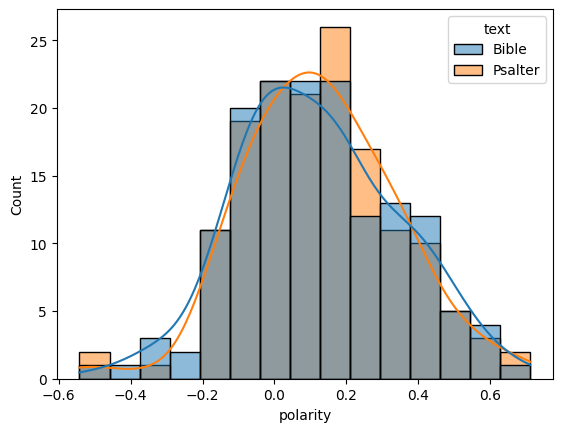

In [52]:
import seaborn as sns

sns.histplot(data=psalms, x="polarity", hue="text", kde=True)

<Axes: xlabel='subjectivity', ylabel='Count'>

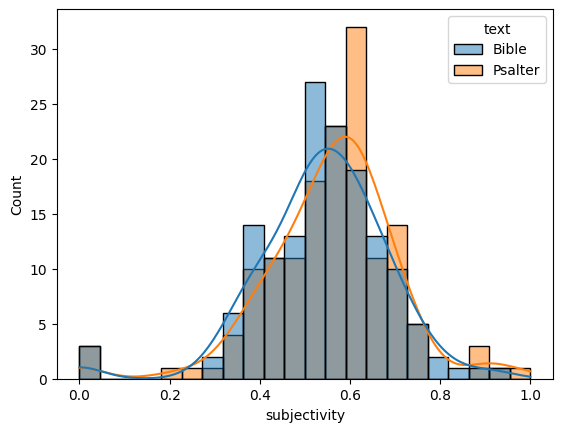

In [53]:
sns.histplot(data=psalms, x="subjectivity", hue="text", kde=True)

## Notes

- The Psalter contains more emotion within the text than the book of Psalms have done. 
- There appears to be mroe subjectivity within the Psalter this is probaly influenced by the great polarity within the Psalter as well. 
    - **Low subjectivity (~0.0–0.3)** → factual, narrative, historical
    - **High subjectivity (~0.6–1.0)** → expressive, emotional, interpretive

## Text Blob Mapping



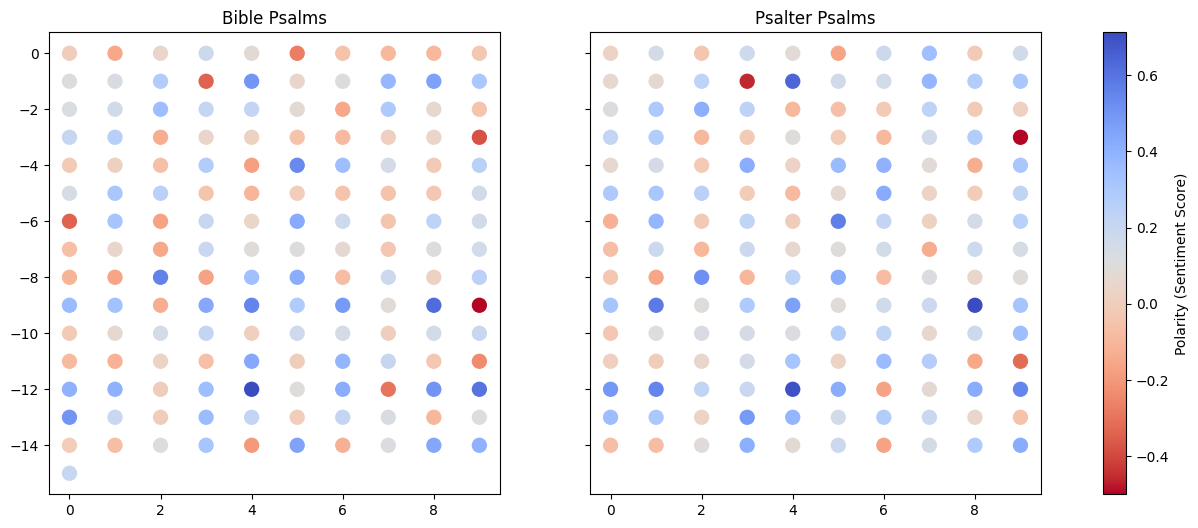

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sc1 = axes[0].scatter(
    bible["col"], -bible["row"],
    c=bible["polarity"],
    cmap="coolwarm_r",
    s=100
)
axes[0].set_title("Bible Psalms")

sc2 = axes[1].scatter(
    psalter["col"], -psalter["row"],
    c=psalter["polarity"],
    cmap="coolwarm_r",
    s=100
)
axes[1].set_title("Psalter Psalms")

cbar = plt.colorbar(sc1, ax=axes)
cbar.set_label("Polarity (Sentiment Score)") 

plt.show()

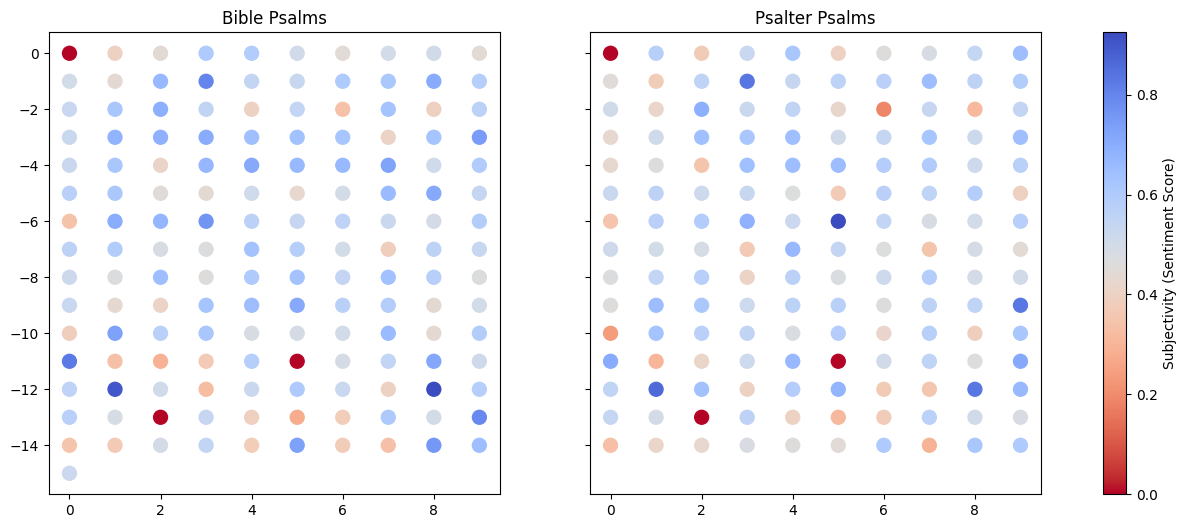

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sc1 = axes[0].scatter(
    bible["col"], -bible["row"],
    c=bible["subjectivity"],
    cmap="coolwarm_r",
    s=100
)
axes[0].set_title("Bible Psalms")

sc2 = axes[1].scatter(
    psalter["col"], -psalter["row"],
    c=psalter["subjectivity"],
    cmap="coolwarm_r",
    s=100
)
axes[1].set_title("Psalter Psalms")

cbar = plt.colorbar(sc1, ax=axes)
cbar.set_label("Subjectivity (Sentiment Score)") 

plt.show()

In [39]:
psalms['emotional_score'] = psalms['polarity'] * psalms['subjectivity']

In [40]:
bible = psalms[psalms["text"] == "Bible"].copy().reset_index(drop=True)
psalter = psalms[psalms["text"] == "Psalter"] .copy().reset_index(drop=True)


bible["row"] = bible.index // 10
bible["col"] = bible.index % 10


psalter["row"] = psalter.index // 10
psalter["col"] = psalter.index % 10

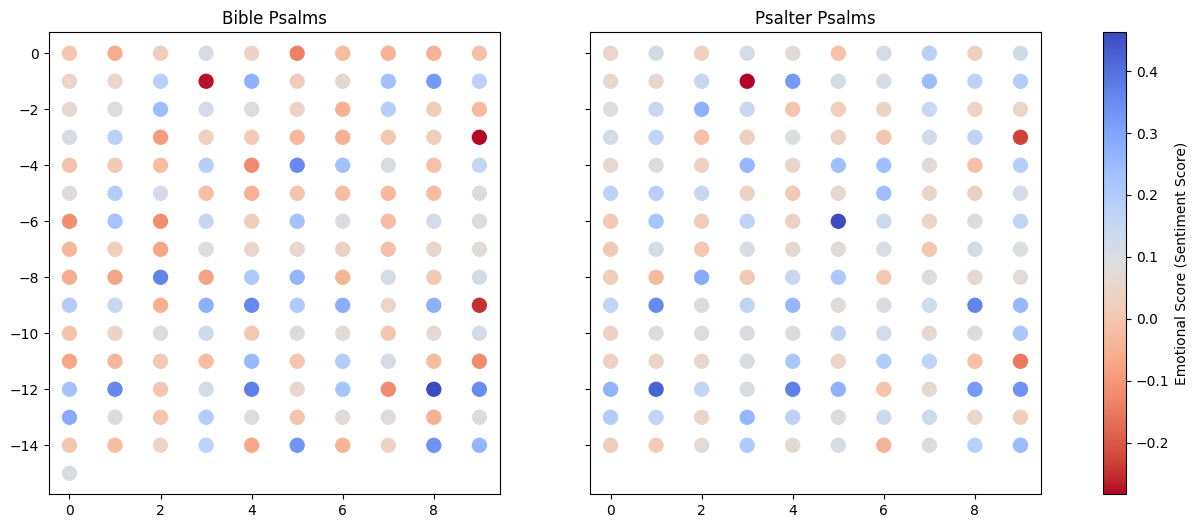

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sc1 = axes[0].scatter(
    bible["col"], -bible["row"],
    c=bible["emotional_score"],
    cmap="coolwarm_r",
    s=100
)
axes[0].set_title("Bible Psalms")

sc2 = axes[1].scatter(
    psalter["col"], -psalter["row"],
    c=psalter["emotional_score"],
    cmap="coolwarm_r",
    s=100
)
axes[1].set_title("Psalter Psalms")

cbar = plt.colorbar(sc1, ax=axes)
cbar.set_label("Emotional Score (Sentiment Score)") 

plt.show()

In [42]:
psalms.tail(20)

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,vader_score,neg,neu,pos,compound,vader_category,polarity,subjectivity,emotional_score
281,281,Orthodox,Psalter,131,"Lord, remember David and all his meekness; how...","lord , remember david meekness ; sware unto lo...","{'neg': 0.022, 'neu': 0.909, 'pos': 0.069, 'co...",0.022,0.909,0.069,0.7935,Positive,0.333333,0.583333,0.194444
282,282,Orthodox,Psalter,132,"Behold now, what is so good or so pleasant as ...","behold now , good pleasant brother dwell toget...","{'neg': 0.0, 'neu': 0.813, 'pos': 0.187, 'comp...",0.000,0.813,0.187,0.9265,Positive,0.280556,0.536111,0.150409
283,283,Orthodox,Psalter,133,"Behold now, bless ye the Lord, all ye servants...","behold now , bless ye lord , ye servant lord ,...","{'neg': 0.0, 'neu': 0.78, 'pos': 0.22, 'compou...",0.000,0.780,0.220,0.9153,Positive,0.000000,0.000000,0.000000
284,284,Orthodox,Psalter,134,"Praise ye the name of the Lord; O ye servants,...","praise ye name lord ; ye servant , praise lord...","{'neg': 0.013, 'neu': 0.857, 'pos': 0.131, 'co...",0.013,0.857,0.131,0.9880,Positive,0.462500,0.606250,0.280391
285,285,Orthodox,Psalter,135,"O give thanks unto the Lord, for He is good; f...","give thanks unto lord , good ; mercy endureth ...","{'neg': 0.022, 'neu': 0.71, 'pos': 0.268, 'com...",0.022,0.710,0.268,0.9983,Positive,0.364103,0.429487,0.156377
286,286,Orthodox,Psalter,136,"By the rivers of Babylon, there we sat down an...","river babylon , sat wept , remembered zion . h...","{'neg': 0.049, 'neu': 0.829, 'pos': 0.122, 'co...",0.049,0.829,0.122,0.9442,Positive,0.127523,0.339229,0.043259
287,287,Orthodox,Psalter,137,"I will give Thee thanks, O Lord, with my whole...","give thee thanks , lord , whole heart : angel ...","{'neg': 0.057, 'neu': 0.747, 'pos': 0.196, 'co...",0.057,0.747,0.196,0.9786,Positive,0.252976,0.402976,0.101943
288,288,Orthodox,Psalter,138,"O Lord, Thou hast proved me, and Thou knowest ...","lord , thou hast proved me , thou knowest me ....","{'neg': 0.105, 'neu': 0.748, 'pos': 0.148, 'co...",0.105,0.748,0.148,0.9492,Positive,0.166994,0.614700,0.102651
289,289,Orthodox,Psalter,139,"Rescue me, O Lord, from the evil man; deliver ...","rescue me , lord , evil man ; deliver unrighte...","{'neg': 0.146, 'neu': 0.735, 'pos': 0.119, 'co...",0.146,0.735,0.119,-0.8860,Negative,0.020018,0.545944,0.010928
290,290,Orthodox,Psalter,140,"Lord, I have cried unto Thee, hear Thou me; gi...","lord , cried unto thee , hear thou me ; give e...","{'neg': 0.105, 'neu': 0.817, 'pos': 0.078, 'co...",0.105,0.817,0.078,-0.6362,Negative,-0.083333,0.516667,-0.043056


# BERTopic Modeling

In [43]:
#%pip install bertopic

%pip install --force-reinstall \
    numpy==1.26.4 \
    scikit-learn==1.3.2 \
    umap-learn==0.5.5 \
    numba==0.58.1 \
    bertopic

In [44]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [45]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")
topic_model = BERTopic(embedding_model=embedding_model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [46]:
docs = psalms["verse"].astype(str).tolist()

In [47]:
topics, probs = topic_model.fit_transform(docs)